# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [2]:
# choropleth of total_gdp
fig_total = px.choropleth(gap_latest, locations="iso_alpha", color="total_gdp",
                           hover_name="country", color_continuous_scale="Blues",
                           title="Total GDP by Country (2007) -- a 'count' choropleth")
fig_total.show()

# choropleth of gdpPercap
fig_rate = px.choropleth(gap_latest, locations="iso_alpha", color="gdpPercap",
                          hover_name="country", color_continuous_scale="Blues",
                          title="GDP per Capita by Country (2007) -- a 'rate' choropleth")
fig_rate.show()

# top 5 countries by each -- print both lists
top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp"]]
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "gdpPercap"]]
print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)

Top 5 by total GDP:
            country     total_gdp
134  United States  1.293446e+13
24           China  6.539501e+12
66           Japan  4.035135e+12
58           India  2.722925e+12
47         Germany  2.650871e+12

Top 5 by GDP per capita:
            country    gdpPercap
95          Norway  49357.19017
71          Kuwait  47306.98978
113      Singapore  47143.17964
134  United States  42951.65309
62         Ireland  40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_

Total GDP is topped by United States, China, Japan, India, and Germany -- these are
mostly just the largest *population* countries, since total GDP scales with headcount.
GDP per capita is topped by a completely different set: Norway, Kuwait, Singapore,
United States, and Ireland -- small, wealthy countries that would barely register on
the total-GDP map because they don't have many people. Only the United States shows up
in both. I'd show the director the per-capita map as the default: total GDP mostly just
re-tells you which countries have the most people, which isn't a very useful development
signal on its own, while GDP per capita actually reflects living standards, which is
what a development-focused briefing should lead with.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

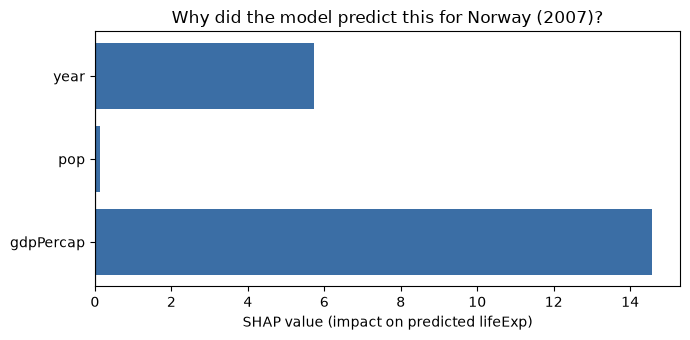

In [3]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# fit the model
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_model, y_model)

# SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# find Norway's row, plot its SHAP contributions
row_idx = gapminder[(gapminder.country == "Norway") & (gapminder.year == 2007)].index[0]
vals = shap_values[row_idx]
feature_names = ["gdpPercap", "pop", "year"]

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["#3b6ea5" if v >= 0 else "#b5432e" for v in vals]
ax.barh(feature_names, vals, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("SHAP value (impact on predicted lifeExp)")
ax.set_title("Why did the model predict this for Norway (2007)?")
plt.tight_layout()
plt.show()

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_

`gdpPercap` contributed the most positively (SHAP ≈ +14.6 years), with `year` also
contributing a solid positive amount (≈ +5.7 years) -- nothing contributed negatively
for Norway specifically, `pop` was just close to neutral (≈ +0.1). This is *not* quite
the same story the model's global feature importances tell: globally, `gdpPercap` is
clearly the dominant feature (importance ≈ 0.76), but `pop` (≈ 0.13) actually edges out
`year` (≈ 0.10) in the global ranking. For Norway individually, though, `year` mattered
far more than `pop` did. That's the whole point of local explanations -- the global
ranking is an average over every country, and it can hide the fact that, for this one
specific prediction, a feature the model globally treats as "less important than
population" was actually the second-biggest driver.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

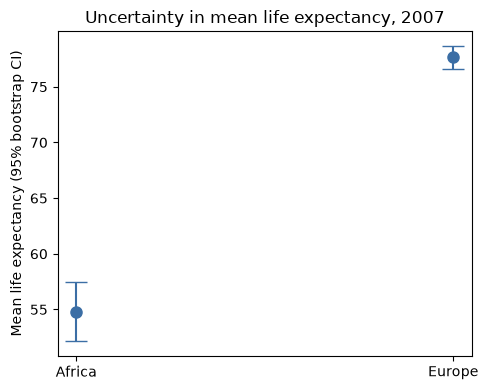

Africa: mean=54.81, 95% CI=(52.15, 57.44)
Europe: mean=77.65, 95% CI=(76.57, 78.65)


In [4]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    # resample `values` with replacement n_boot times, take the mean each time,
    # then return (overall mean, 2.5th percentile of boot means, 97.5th percentile)
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means[i] = sample.mean()
    return values.mean(), np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5)

# compute CIs for two continents of your choice
continent_a, continent_b = "Africa", "Europe"
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

# plot both as error bars (mean +/- CI half-width) on one chart
fig, ax = plt.subplots(figsize=(5, 4))
for i, (name, (mean, lo, hi)) in enumerate([(continent_a, result_a), (continent_b, result_b)]):
    err = [[mean - lo], [hi - mean]]
    ax.errorbar([i], [mean], yerr=err, fmt="o", capsize=8, markersize=8, color="#3b6ea5")
ax.set_xticks([0, 1]); ax.set_xticklabels([continent_a, continent_b])
ax.set_ylabel("Mean life expectancy (95% bootstrap CI)")
ax.set_title("Uncertainty in mean life expectancy, 2007")
plt.tight_layout()
plt.show()

print(f"{continent_a}: mean={result_a[0]:.2f}, 95% CI=({result_a[1]:.2f}, {result_a[2]:.2f})")
print(f"{continent_b}: mean={result_b[0]:.2f}, 95% CI=({result_b[1]:.2f}, {result_b[2]:.2f})")

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
sized (n), or both?

_Your answer:_

**Africa** has the much wider interval (about 5.3 years wide, vs. about 2.1 years for
Europe). It's *not* because of sample size -- Africa actually has more countries in this
data (52) than Europe does (30), which would normally make its interval narrower, not
wider. The real driver is variation: Africa's life expectancy values have a standard
deviation of about 9.6 years across countries, versus only about 3.0 years for Europe.
Europe's countries are just much more similar to each other on this measure, so a
smaller, more consistent sample produces a tighter estimate than a larger but far more
spread-out one.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

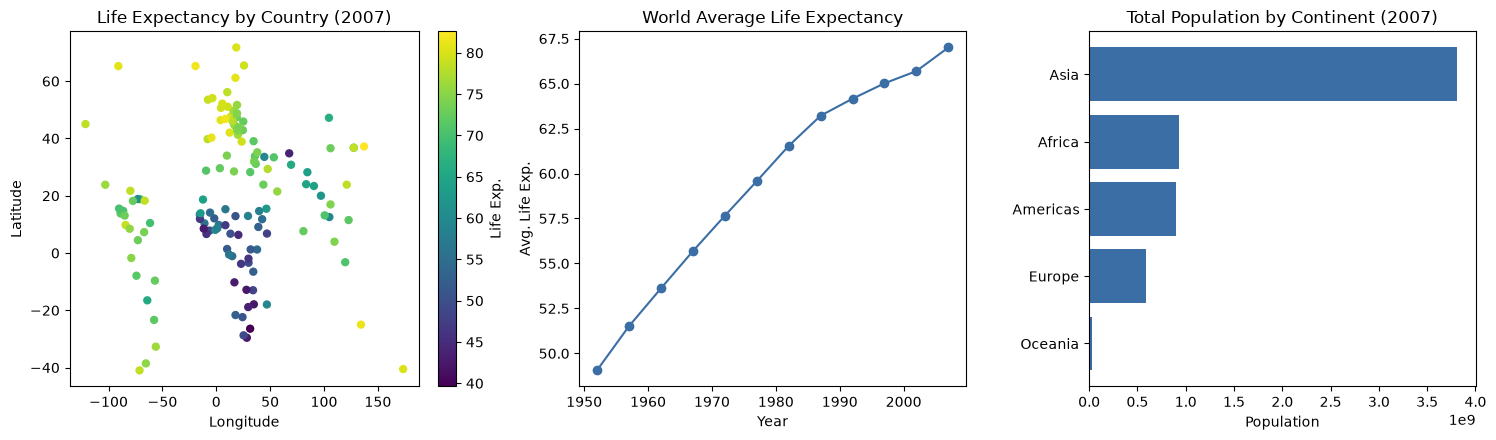

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# map-style scatter (axes[0])
sc = axes[0].scatter(gap_latest["centroid_lon"], gap_latest["centroid_lat"],
                      c=gap_latest["lifeExp"], cmap="viridis", s=25)
axes[0].set_title("Life Expectancy by Country (2007)")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
plt.colorbar(sc, ax=axes[0], fraction=0.046, label="Life Exp.")

# world trend line (axes[1])
world_trend = gapminder.groupby("year")["lifeExp"].mean()
axes[1].plot(world_trend.index, world_trend.values, marker="o", color="#3b6ea5")
axes[1].set_title("World Average Life Expectancy")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Avg. Life Exp.")

# population by continent bar chart (axes[2])
pop_by_continent = gap_latest.groupby("continent")["pop"].sum().sort_values()
axes[2].barh(pop_by_continent.index, pop_by_continent.values, color="#3b6ea5")
axes[2].set_title("Total Population by Continent (2007)")
axes[2].set_xlabel("Population")

plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_

I'd keep the **world trend line**. The map panel is good for spotting a geographic
outlier and the population bar is good for a one-off comparison, but neither one changes
day to day in a way that needs a "morning glance" -- they're closer to reference charts
you'd check occasionally. The trend line is the one panel that directly answers "is
anything changing" at a glance, which per the lecture is exactly what a monitoring
dashboard's morning-glance panel should answer -- it would immediately show if the
world-average trend flattened out or reversed, which is the kind of pattern a director
actually needs to catch early, not after a quarterly report.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4-6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_

For all future maps I'd standardize on the **rate** framing (GDP per capita, not total
GDP) -- the total-GDP map is really just a population map in disguise, since it's
dominated by China, India, and the US purely because of headcount, while the per-capita
map is the one that actually reflects living standards and is what a development
briefing should be about. When a journalist asks about a specific country's predicted
life expectancy, I'd lead with the **local** SHAP explanation, not the global feature
importance -- Norway's case showed those can disagree (globally population edges out
year in importance, but for Norway specifically year mattered far more and population
barely registered), and a global average simply can't answer a question about one
country. Finally, every continent-level average life expectancy in the dashboard should
never be shown as a bare point estimate -- Africa's and Europe's very different
confidence interval widths (5.3 years vs. 2.1 years) show that "the average is X" hides
how much genuine variation sits behind that number, and reporting it without a CI risks
the director quoting a false precision to policymakers.